In [1]:
import torch
from torchvision.datasets import CocoDetection
import os 
import numpy as np 
from PIL import Image 

In [2]:
data_path=r"data\PennFudanPed"

In [3]:
img_path=os.path.join(data_path,"PNGImages",r"E:\DeepLearningToGo\Objectrec\data\PennFudanPed\PNGImages\FudanPed00001.png")
mask_path=os.path.join(data_path,"PedMasks",r"E:\DeepLearningToGo\Objectrec\data\PennFudanPed\PedMasks\FudanPed00001_mask.png")

In [4]:
image = Image.open(img_path)
mask = Image.open(mask_path)

In [5]:
mask_array=np.array(mask)
object_ids=np.unique(mask_array)


In [6]:
print("Image shape:", image.size)
print(object_ids)

Image shape: (559, 536)
[0 1 2]


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [8]:
boxes=[]

person_ids=object_ids[1:] # exclude background

for p_id in person_ids:
    rows , cols = np.where(mask_array==p_id)
    x_min= np.min(cols)
    x_max= np.max(cols)
    y_min= np.min(rows)
    y_max= np.max(rows)

    boxes.append([x_min,y_min,x_max,y_max])
    print(f"Person {p_id} Box [x_min, y_min, x_max, y_max]:", [x_min, y_min, x_max, y_max])

Person 1 Box [x_min, y_min, x_max, y_max]: [np.int64(159), np.int64(181), np.int64(301), np.int64(430)]
Person 2 Box [x_min, y_min, x_max, y_max]: [np.int64(419), np.int64(170), np.int64(534), np.int64(485)]


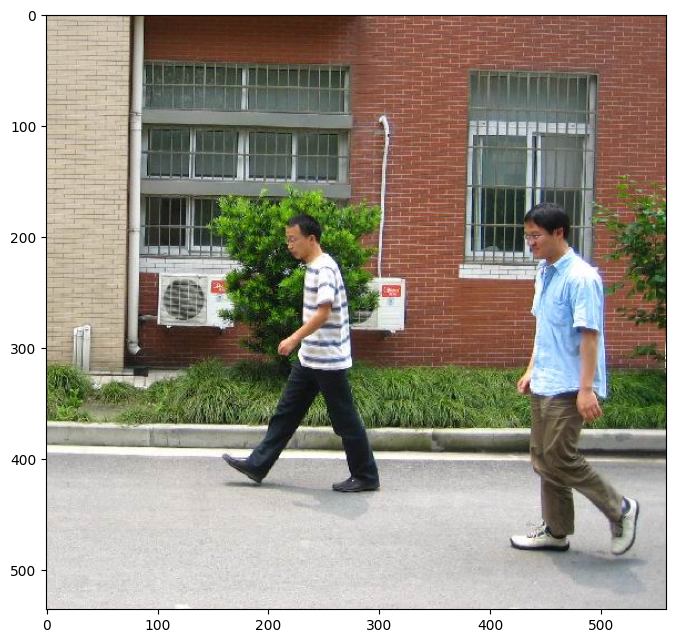

In [9]:
fig , ax = plt.subplots(1,figsize=(8,8))
ax.imshow(image)

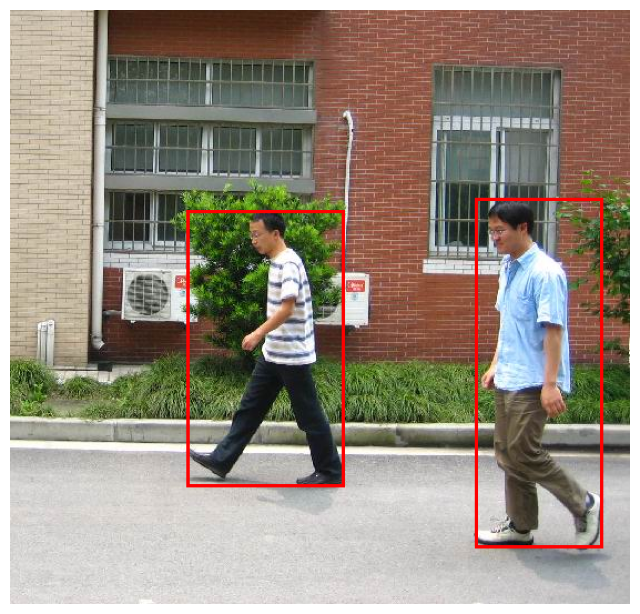

In [10]:
import torch
import torchvision.transforms.v2 as transforms
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt

# 1. Convert PIL image to a PyTorch uint8 Tensor [0 to 255]
img_tensor = transforms.functional.to_image(image) # Shape: [3, H, W]

# 2. Convert calculated boxes list to a PyTorch float Tensor
boxes_tensor = torch.tensor(boxes, dtype=torch.float32)

# 3. Draw bounding boxes directly on the image tensor!
drawn_img = draw_bounding_boxes(
    img_tensor, 
    boxes=boxes_tensor, 
    colors="red", 
    width=3
)

# 4. Display result (permute converts PyTorch's [C, H, W] to Matplotlib's [H, W, C])
plt.figure(figsize=(8, 8))
plt.imshow(drawn_img.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [11]:
from torch.utils.data import Dataset

In [12]:
class PennFudanDataset(Dataset) :
    def __init__(self , root ):
        self.root=root 
        self.imgs=list(sorted(os.listdir(os.path.join(root,"PNGImages"))))
        self.masks=list(sorted(os.listdir(os.path.join(root,"PedMasks"))))
    
    def __getitem__(self, idx):
        img_path=os.path.join(self.root,"PNGImages",self.imgs[idx])
        mask_path=os.path.join(self.root,"PedMasks",self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        obj_ids = np.unique(mask)[1:]  # exclude background
        boxes=[]
        for p_id in obj_ids:
            rows , cols = np.where(mask==p_id)
            x_min= np.min(cols)
            x_max= np.max(cols)
            y_min= np.min(rows)
            y_max= np.max(rows)

            boxes.append([x_min,y_min,x_max,y_max])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((len(obj_ids),), dtype=torch.int64)  # all

        target={"boxes":boxes,
        "labels":labels}

        img_tensor=transforms.functional.to_image(img)
        img_tensor=transforms.functional.to_dtype(img_tensor , dtype=torch.float32)

        return img_tensor , target
    def __len__(self):
        return len(self.imgs)    

In [13]:
dataset = PennFudanDataset(r"E:\DeepLearningToGo\Objectrec\data\PennFudanPed")
img, target = dataset[0]
print(img.shape, target)

torch.Size([3, 536, 559]) {'boxes': tensor([[159., 181., 301., 430.],
        [419., 170., 534., 485.]]), 'labels': tensor([1, 1])}


In [17]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn

In [25]:
class ObjectDetectorCNN(nn.Module):
    def __init__(self):
        super(ObjectDetectorCNN, self).__init__()
        mobilenet=mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        self.backbone=nn.Sequential(*list(mobilenet.children())[:-1])
        input_features=nn.Sequential(*list(mobilenet.children())[-1].children())[1].in_features

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier=nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Linear(512,2))

        self.regressor=nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU(),
            nn.Linear(32,4))

    def forward(self,x):
        features=self.backbone(x)
        features = self.pool(features) # <-- Shrinks [1, 1280, H, W] to [1, 1280, 1, 1]
        features=torch.flatten(features,1)
        classes= self.classifier(features)
        bboxes= self.regressor(features)

        return  bboxes , classes          

In [26]:
model = ObjectDetectorCNN()

# Prepare 1 sample image tensor (add batch dimension with unsqueeze)
sample_image = img.unsqueeze(0) # Shape: [1, 3, 536, 559]

# Run forward pass
predicted_bboxes, predicted_classes = model(sample_image)

print("Predicted Bounding Boxes Shape:", predicted_bboxes.shape) # Should be [1, 4]
print("Predicted Class Logits Shape:", predicted_classes.shape)  # Should be [1, 2]

Predicted Bounding Boxes Shape: torch.Size([1, 4])
Predicted Class Logits Shape: torch.Size([1, 2])
